In [1]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt
data=pd.read_csv("Transformed_Housing_Data2.csv")
data.head()

,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
0,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,0,...,0,0,0,0,0,0,0,0,0,0
1,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,400,...,0,0,1,0,0,0,0,0,0,0
2,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,0,...,0,0,1,0,0,0,0,0,0,0
3,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,910,...,0,0,0,1,0,0,0,0,0,0
4,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,0,...,0,0,0,0,1,0,0,0,0,0


In [2]:
sale_price = data['Sale_Price'].head(30)
flat_area = data['Flat Area (in Sqft)'].head(30)
sample_data = pd.DataFrame({ 'sale_price': sale_price,'flat_area': flat_area})
sample_data

,sale_price,flat_area
0,221900.0,1180.0
1,538000.0,2570.0
2,180000.0,770.0
3,604000.0,1960.0
4,510000.0,1680.0
5,1129575.0,5420.0
6,257500.0,1715.0
7,291850.0,1060.0
8,229500.0,1780.0
9,323000.0,1890.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<function matplotlib.pyplot.show(close=None, block=None)>

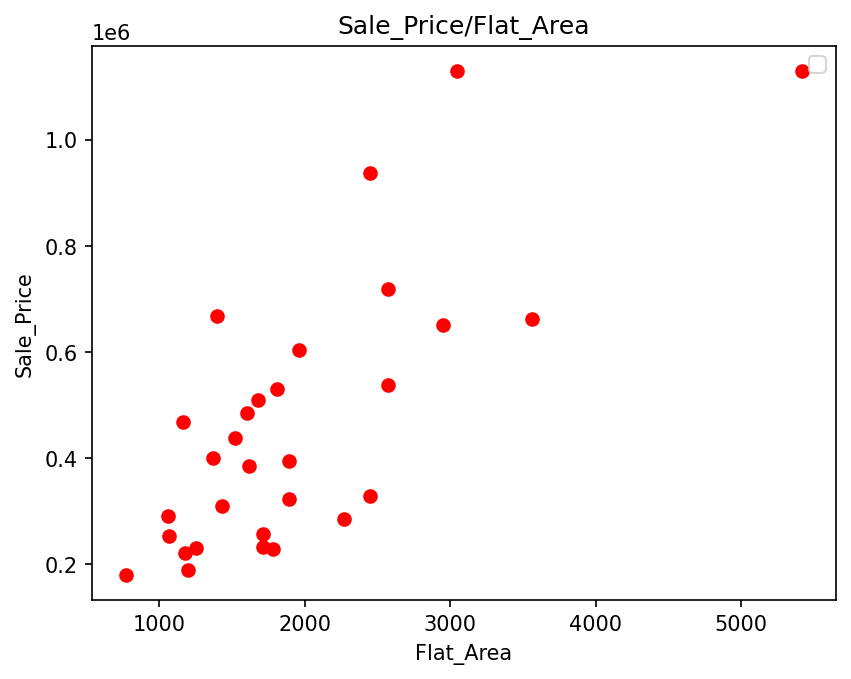

In [4]:
plt.figure( dpi = 150)
plt.scatter(sample_data.flat_area, sample_data.sale_price, color = 'red')
plt.xlabel('Flat_Area')
plt.ylabel('Sale_Price')
plt.title('Sale_Price/Flat_Area')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

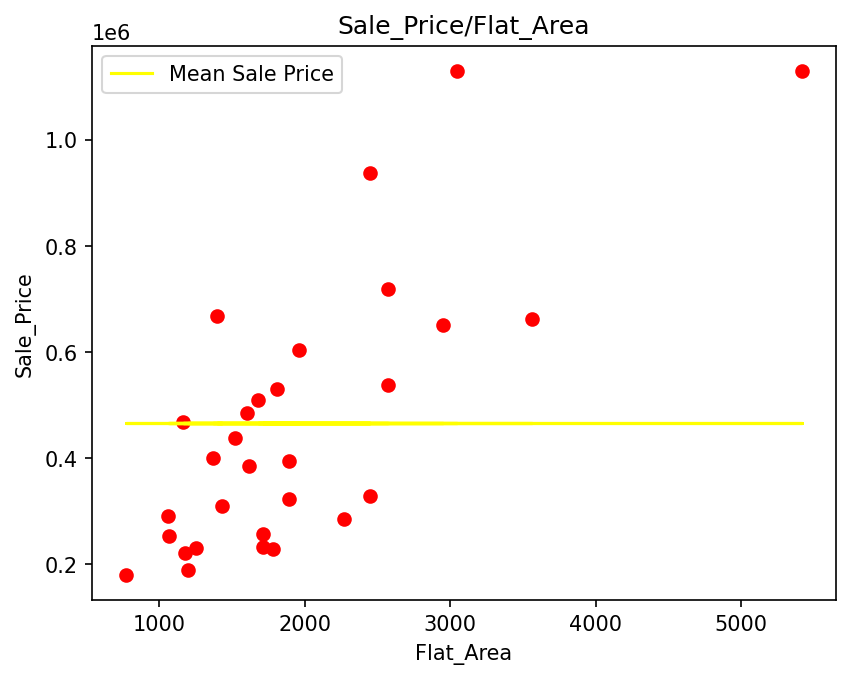

In [5]:
sample_data['mean_sale_price'] = sample_data.sale_price.mean()

plt.figure( dpi = 150)
plt.scatter(sample_data.flat_area, sample_data.sale_price, color = 'red')
plt.plot(sample_data.flat_area, sample_data.mean_sale_price, color = 'yellow',label = 'Mean Sale Price')
plt.xlabel('Flat_Area')
plt.ylabel('Sale_Price')
plt.title('Sale_Price/Flat_Area')
plt.legend()
plt.show

Text(0.5, 1.0, 'slope0with MSE281372081125.0')

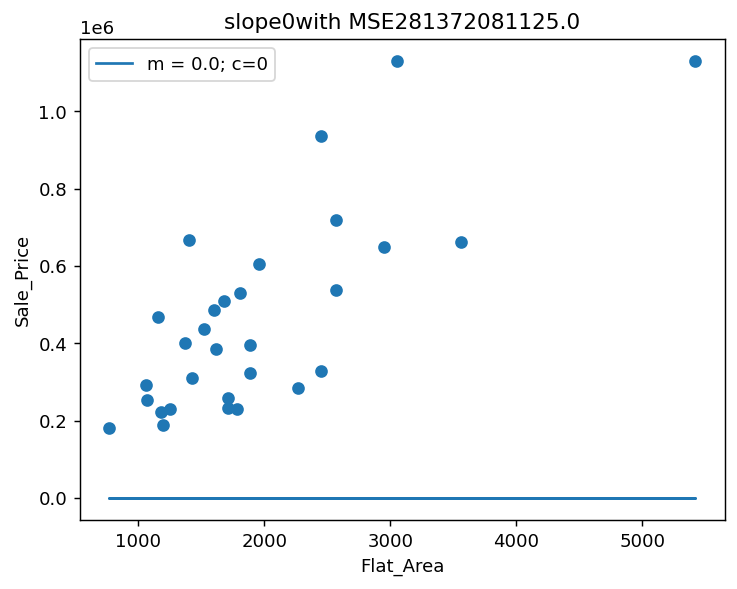

In [7]:
def mse(actual,predicted):
    return((actual - predicted) ** 2).mean()
c=0 
m=0

line = []

for i in range(len(sample_data)):
    line.append(sample_data.flat_area[i] * m + c)
    
plt.figure (dpi = 130) 
plt.scatter(sample_data.flat_area, sample_data.sale_price)
plt.plot(sample_data.flat_area, line, label = 'm = 0.0; c=0')
plt.xlabel('Flat_Area')
plt.ylabel('Sale_Price')
plt.legend()
MSE = mse(sample_data.sale_price, line)
plt.title('slope'+str(m)+'with MSE' + str(MSE))

In [10]:
def slope_Error( slope, intercept, sample_data):
    sale=[]
    for i in range(len(sample_data.flat_area)):
        tmp = sample_data.flat_area[i] * slope + intercept
        sale.append(tmp)
    MSE = mse(sample_data.sale_price, sale)
    return MSE

In [12]:
slope = [i/10 for i in range(0,5000)]
Cost = []
for i in slope:
    cost = slope_Error(slope = i, intercept = 0, sample_data = sample_data)
    Cost.append(cost)

In [13]:
#Arranging in DataFrame
Cost_table = pd.DataFrame({
    'slope' : slope,
    'Cost' : Cost
})
Cost_table.tail()

,slope,Cost
4995,499.5,3.526038e+11
4996,499.6,3.528488e+11
4997,499.7,3.530938e+11
4998,499.8,3.533389e+11
4999,499.9,3.535842e+11


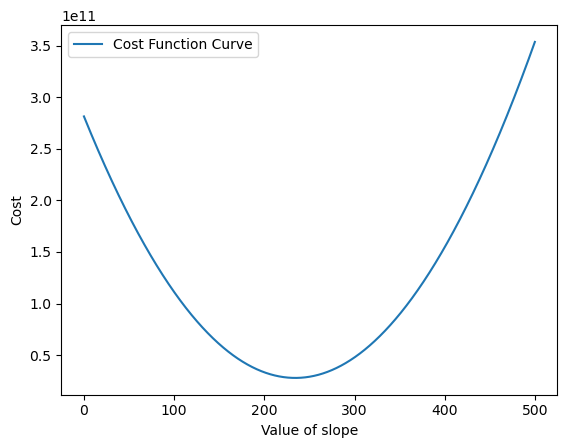

In [14]:
# plotting the cost values corresponding to every value of Beta
plt.plot(Cost_table.slope, Cost_table.Cost, label = 'Cost Function Curve')
plt.xlabel('Value of slope')
plt.ylabel('Cost')
plt.legend()

In [18]:
def intercept_Error(slope, intercept,sample_data):
    sale=[]
    for i in range(len(sample_data.flat_area)):
        tmp = sample_data.flat_area[i] * slope +intercept
        sale.append(tmp)
    MSE = mse(sample_data.sale_price, sale)
    return MSE

In [19]:
intercept = [i for i in range(5000, 50000)]
Cost = []
for i in intercept:
    cost = intercept_Error(slope = 234, intercept = i, sample_data = sample_data)
    Cost.append(cost)

In [20]:
#Arranging in DataFrame
Cost_table = pd.DataFrame({
    'intercept' : intercept,
    'Cost' : Cost
})
Cost_table.tail()

,intercept,Cost
44995,49995,2.929862e+10
44996,49996,2.929870e+10
44997,49997,2.929878e+10
44998,49998,2.929886e+10
44999,49999,2.929894e+10


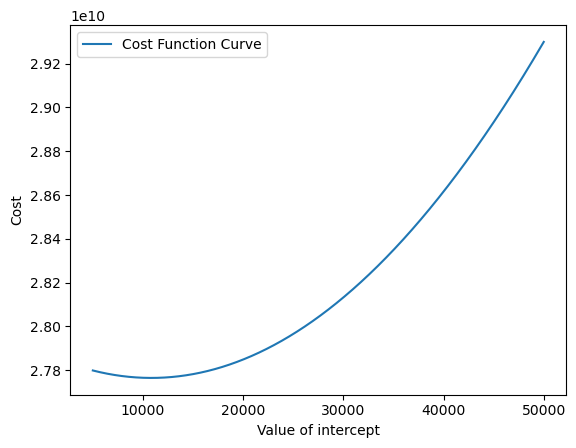

In [21]:
# plotting the cost values corresponding to every value of Beta
plt.plot(Cost_table.intercept, Cost_table.Cost, label = 'Cost Function Curve')
plt.xlabel('Value of intercept')
plt.ylabel('Cost')
plt.legend()

In [22]:
slope = [i/10 for i in range(0,5000)]
Cost = []
for i in slope:
    cost = slope_Error(slope = i, intercept = 10834, sample_data = sample_data)
    Cost.append(cost)

In [23]:
#Arranging in DataFrame
Cost_table = pd.DataFrame({
    'slope' : slope,
    'Cost' : Cost
})
Cost_table.tail()

,slope,Cost
4995,499.5,3.636767e+11
4996,499.6,3.639259e+11
4997,499.7,3.641751e+11
4998,499.8,3.644245e+11
4999,499.9,3.646739e+11


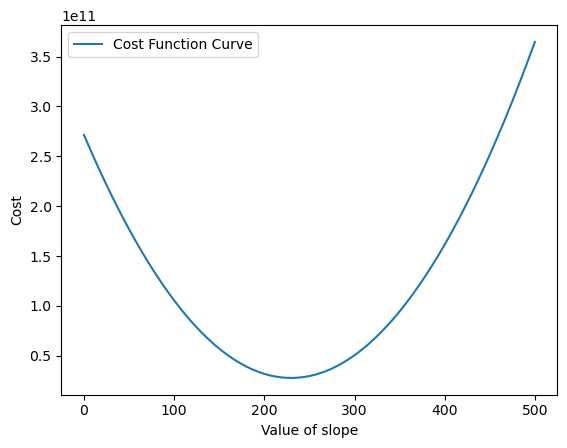

In [24]:
# plotting the cost values corresponding to every value of Beta
plt.plot(Cost_table.slope, Cost_table.Cost, label = 'Cost Function Curve')
plt.xlabel('Value of slope')
plt.ylabel('Cost')
plt.legend()

In [25]:
new_slope = Cost_table['slope'][Cost_table['Cost'] == Cost_table['Cost'].min()].values
new_slope[0]

229.7

In [26]:
def param_init(Y):  #This function takes only the target variable as its parameter.
    '''
    Y = target variable 
    returns initialized values of m and c
    '''
    m = 0.1
    c = Y.mean()
    return m, c

In [27]:
def generate_predictions(m, c, X):
    '''
    X = independent variable
    returns prediction generated by line with parameters m, c
    '''
    prediction = []
    for x in X:
        pred = (m * x) + c
        prediction.append(pred)
    return prediction    

In [28]:
def compute_cost(prediction, Y):
    '''
    returns the mean_squared_error between prediction and Y
    '''
    cost = np.sum(((prediction - Y)**2)/len(Y))
    return cost

In [29]:
def gradients(prediction, Y, X):
    '''
    returns Gradients corresponding to m and c
    '''
    n = len(Y)
    Gm = 2/n * np.sum((prediction - Y) * X)
    Gc = 2/n * np.sum((prediction - Y))
    return Gm, Gc

In [30]:
def param_update(m_old, c_old, Gm_old, Gc_old, alpha):
    '''
    update and return the new values of m and c
    '''
    m_new = m_old - alpha * Gm_old
    c_new = c_old - alpha * Gc_old
    return m_new, c_new

In [37]:
def result(m, c, X, Y, cost, predictions, i):
    '''
    Print and Plot the final result from gradient descent
    '''
    ##IF the Gradient Descent converged to the optimum value before man_iter
    if i < max_iter - 1:
        print("***** Gradient Descent has converged at iteration {} *****".format(i))
    else:
        print('***** Result after', max_iter,'iterations is:*****')
            
    ## plotting the final result         
    plt.figure(figsize = (14,7), dpi = 120)
    plt.scatter(X, Y, color = 'red', label = 'data points')
    label = 'final regression line: m = {}; c={}'.format(str(m), str(c))
    plt.plot(X, predictions, color = 'green', label = label)
    plt.xlabel('flat_area')
    plt.ylabel('sale_price')
    plt.title('final regression line')
    plt.legend()

After Iteration 0 : m = 3499072.307222223 ; c= 465999.44299999997 ; Cost = 64177937552.075005
After Iteration 20 : m = 7.115927055971628e+105 ; c= 2.997778392048355e+102 ; Cost = 2.7417231010181384e+208
After Iteration 40 : m = 1.447154337383132e+205 ; c= 6.096532424296826e+201 ; Cost = inf
After Iteration 60 : m = 2.9430538842431367e+304 ; c= 1.2398417341018387e+301 ; Cost = inf
After Iteration 80 : m = nan ; c= nan ; Cost = nan
After Iteration 100 : m = nan ; c= nan ; Cost = nan
After Iteration 120 : m = nan ; c= nan ; Cost = nan
After Iteration 140 : m = nan ; c= nan ; Cost = nan
After Iteration 160 : m = nan ; c= nan ; Cost = nan
After Iteration 180 : m = nan ; c= nan ; Cost = nan
After Iteration 200 : m = nan ; c= nan ; Cost = nan
After Iteration 220 : m = nan ; c= nan ; Cost = nan
After Iteration 240 : m = nan ; c= nan ; Cost = nan
After Iteration 260 : m = nan ; c= nan ; Cost = nan
After Iteration 280 : m = nan ; c= nan ; Cost = nan
After Iteration 300 : m = nan ; c= nan ; Cost 

C:\Users\uttam\AppData\Local\Temp\ipykernel_5632\1176665673.py:5: RuntimeWarning: overflow encountered in square
  cost = np.sum(((prediction - Y)**2)/len(Y))
C:\Users\uttam\AppData\Local\Temp\ipykernel_5632\1131027909.py:23: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(cost_new - cost_old) < 10**(-7):
C:\Users\uttam\AppData\Local\Temp\ipykernel_5632\3036816744.py:6: RuntimeWarning: overflow encountered in multiply
  Gm = 2/n * np.sum((prediction - Y) * X)
C:\Users\uttam\AppData\Local\Temp\ipykernel_5632\2889694576.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  m_new = m_old - alpha * Gm_old
C:\Users\uttam\AppData\Local\Temp\ipykernel_5632\2889694576.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  c_new = c_old - alpha * Gc_old


After Iteration 760 : m = nan ; c= nan ; Cost = nan
After Iteration 780 : m = nan ; c= nan ; Cost = nan
After Iteration 800 : m = nan ; c= nan ; Cost = nan
After Iteration 820 : m = nan ; c= nan ; Cost = nan
After Iteration 840 : m = nan ; c= nan ; Cost = nan
After Iteration 860 : m = nan ; c= nan ; Cost = nan
After Iteration 880 : m = nan ; c= nan ; Cost = nan
After Iteration 900 : m = nan ; c= nan ; Cost = nan
After Iteration 920 : m = nan ; c= nan ; Cost = nan
After Iteration 940 : m = nan ; c= nan ; Cost = nan
After Iteration 960 : m = nan ; c= nan ; Cost = nan
After Iteration 980 : m = nan ; c= nan ; Cost = nan
***** Result after 1000 iterations is:*****


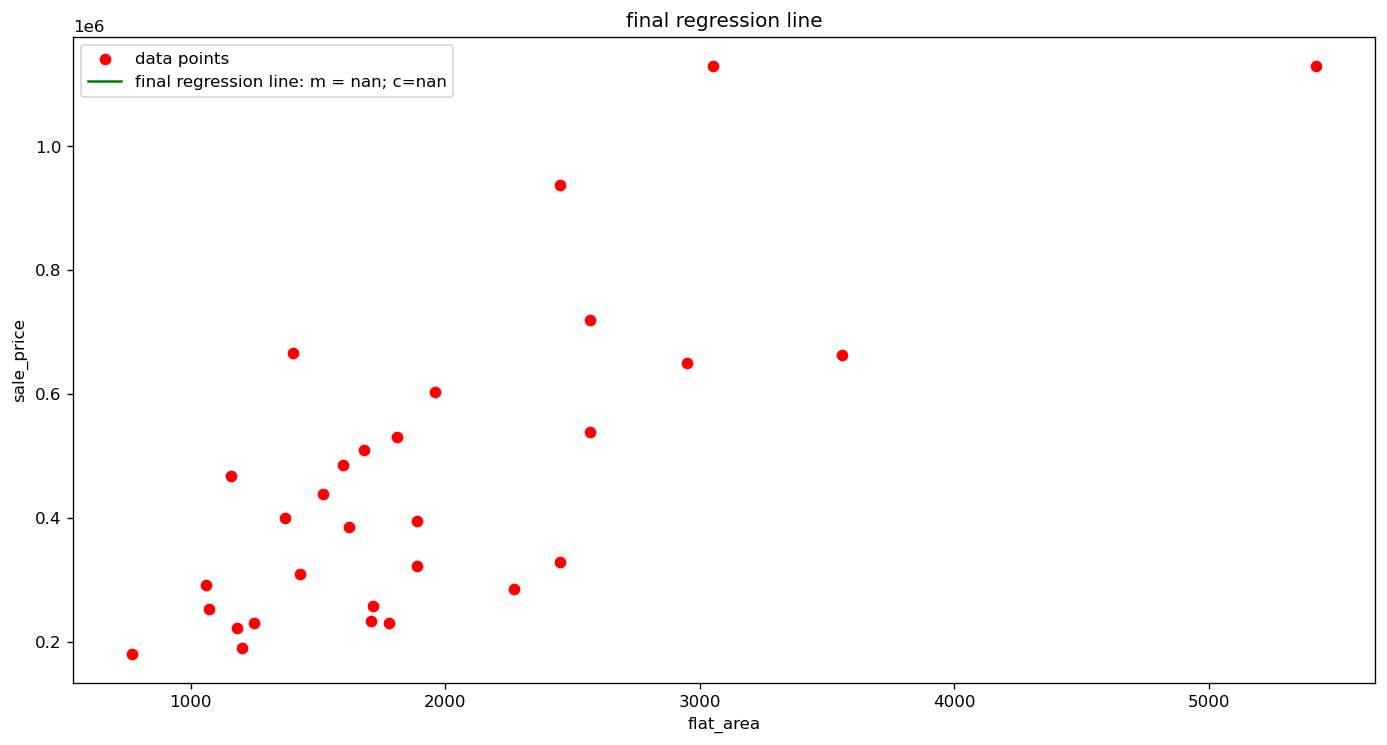

In [38]:
## defining and reshaping the dataset
sale_price = sample_data['sale_price'].values.reshape(-1,1)
flat_area = sample_data['flat_area'].values.reshape(-1,1)

## declaring parameters
max_iter = 1000
cost_old = 0
alpha = 0.01

##Step1: initializing the values of m, c
m, c = param_init(sale_price)

##Gradient Descent in action
for i in range(0, max_iter):
    
    ##Step2: generating predicitions
    predictions = generate_predictions(m, c, flat_area)
    
    ##Step3: calculating cost
    cost_new = compute_cost(predictions, sale_price)
    
    ##checking if GD converged
    if abs(cost_new - cost_old) < 10**(-7):
        break
        
    ##calcula6ting gradients
    Gm, Gc = gradients(predictions, sale_price, flat_area)
        
    ##Step4: updating parameters m and c
    m, c = param_update(m ,c ,Gm , Gc, alpha)
    
    ##display result after every 20 iterations
    if i%20 == 0:
        print('After Iteration', i,': m =', m, '; c=', c,'; Cost =', cost_new)
        
    ##updating cost_old
    cost_old = cost_new
    
## final results
result(m, c, flat_area, sale_price,
      cost_new, predictions, i)

After Iteration 0 : m = 0.11316346413633305 ; c= 1.1849780416165836e-16 ; Cost = 0.85836535863667
After Iteration 20 : m = 0.3275595607435688 ; c= 1.240489192847842e-16 ; Cost = 0.6182472245590185
After Iteration 40 : m = 0.4706921039517346 ; c= 1.3248661427193537e-16 ; Cost = 0.5112264752046607
After Iteration 60 : m = 0.5662485308150865 ; c= 1.415904430738617e-16 ; Cost = 0.46352728398628984
After Iteration 80 : m = 0.6300427631414932 ; c= 1.4951003398285442e-16 ; Cost = 0.4422677351921283
After Iteration 100 : m = 0.6726323011945988 ; c= 1.611303683072644e-16 ; Cost = 0.4327923457067555
After Iteration 120 : m = 0.7010654163122192 ; c= 1.666074685620818e-16 ; Cost = 0.42856916078553225
After Iteration 140 : m = 0.7200475906265729 ; c= 1.6660746856208182e-16 ; Cost = 0.4266868855601835
After Iteration 160 : m = 0.7327202415200801 ; c= 1.669405354694694e-16 ; Cost = 0.42584795473189874
After Iteration 180 : m = 0.7411806042798547 ; c= 1.6694053546946945e-16 ; Cost = 0.4254740429228452

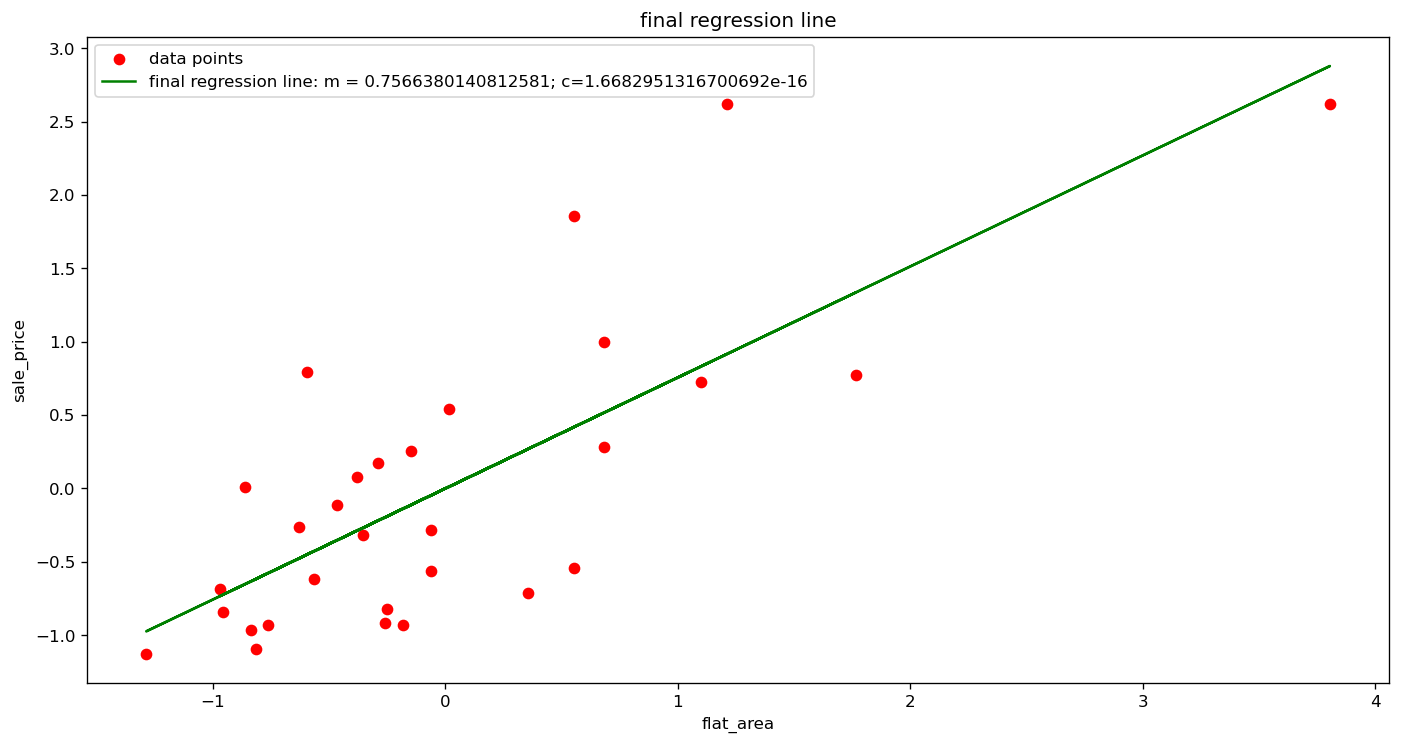

In [43]:
# scaling the dataset using the standard scaler
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
sale_price = scaler.fit_transform(sample_data['sale_price'].values.reshape(-1,1))
flat_area = scaler.fit_transform(sample_data['flat_area'].values.reshape(-1,1))

##declarting parameters
max_iter = 1000
cost_old = 0
alpha = 0.01

##Step1: initializing the values of m,c:
m, c = param_init(sale_price)

##Gradient Descent in action
for i in range(0, max_iter):
    
    ##Step2: generating predicitions
    predictions = generate_predictions(m, c, flat_area)
    
    ##Step3: calculating cost
    cost_new = compute_cost(predictions, sale_price)
    
    ##checking if GD converged
    if abs(cost_new - cost_old) < 10**(-7):
        break
        
    ##calcula6ting gradients
    Gm, Gc = gradients(predictions, sale_price, flat_area)
        
    ##Step4: updating parameters m and c
    m, c = param_update(m ,c ,Gm , Gc, alpha)
    
    ##display result after every 20 iterations
    if i%20 == 0:
        print('After Iteration', i,': m =', m, '; c=', c,'; Cost =', cost_new)
        
    ##updating cost_old
    cost_old = cost_new
    
##final results
result(m, c, flat_area, sale_price,
      cost_new, predictions, i)   

In [1]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt
data=pd.read_csv("Transformed_Housing_Data2.csv")
data.head()

,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
0,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,0,...,0,0,0,0,0,0,0,0,0,0
1,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,400,...,0,0,1,0,0,0,0,0,0,0
2,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,0,...,0,0,1,0,0,0,0,0,0,0
3,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,910,...,0,0,0,1,0,0,0,0,0,0
4,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,0,...,0,0,0,0,1,0,0,0,0,0


In [2]:
data.isnull().sum()

Sale_Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
No of Times Visited                          0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
Years Since Renovation                       0
Condition_of_the_House_Excellent             0
Condition_of_the_House_Fair                  0
Condition_of_the_House_Good                  0
Condition_of_the_House_Okay                  0
Ever_Renovated_Yes                           0
Waterfront_Vi

In [3]:
data.head().shape

(5, 31)

In [9]:
data = pd.read_csv('Raw_Housing_Prices2.csv')
data.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [10]:
sum(data.isnull().sum())

19485

# Feature Transformation

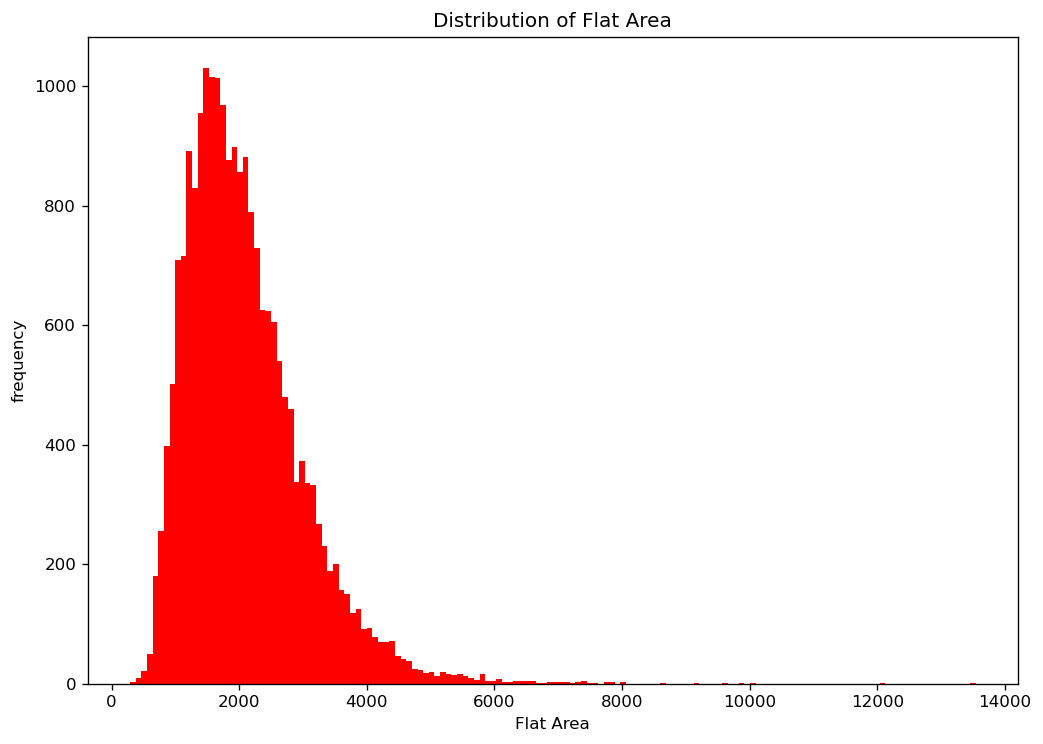

In [11]:
plt.figure( figsize = (10,7), dpi = 120)
plt.hist(data['Flat Area (in Sqft)'], bins = 150, color = 'red')
plt.xlabel('Flat Area')
plt.ylabel('frequency')
plt.title('Distribution of Flat Area')
plt.show()

In [12]:
def log_transform(sample_data):
    return np.log(sample_data)

In [13]:
data['Transform Flat Area'] = data['Flat Area (in Sqft)'].map(log_transform)

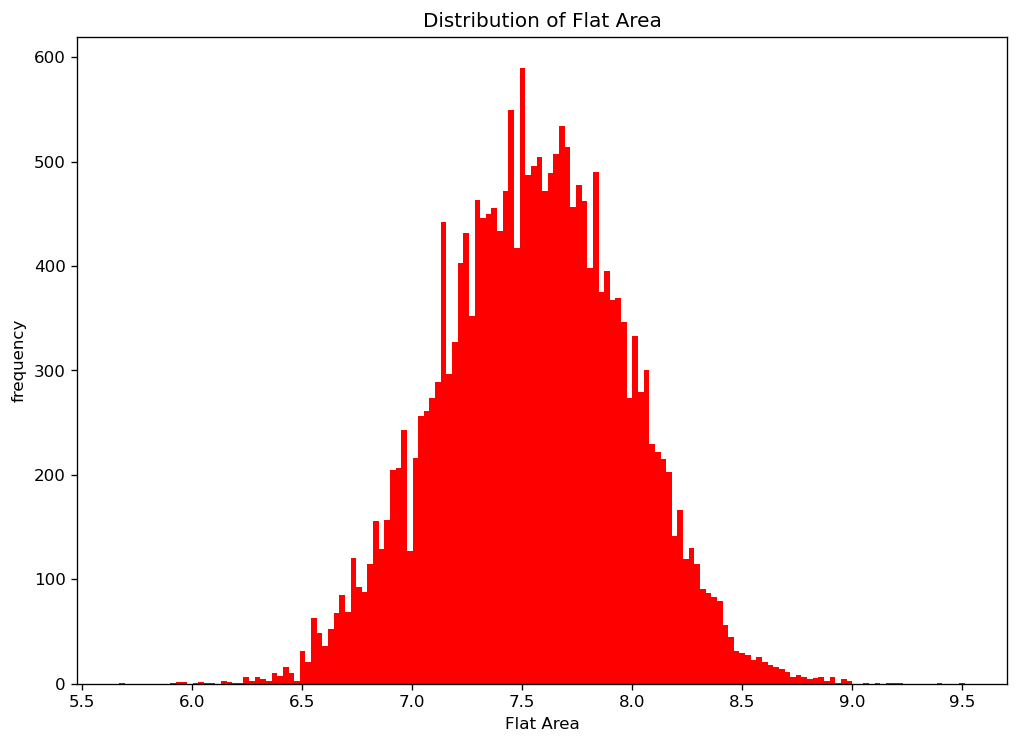

In [14]:
plt.figure( figsize = (10,7), dpi = 120)
plt.hist(data['Transform Flat Area'], bins = 150, color = 'red')
plt.xlabel('Flat Area')
plt.ylabel('frequency')
plt.title('Distribution of Flat Area')
plt.show()

In [15]:
 label_encoded = data['Condition of the House']
 label_encoded.value_counts()   

Condition of the House
Fair         14028
Good          5678
Excellent     1701
Okay           172
Bad             30
Name: count, dtype: int64

In [16]:
label_encoded = label_encoded.map({ 'Bad':1,
                                    'Okay':2,
                                    'Fair':3,
                                    'Good':4,
                                    'Excellent':5})
label_encoded.value_counts()

Condition of the House
3    14028
4     5678
5     1701
2      172
1       30
Name: count, dtype: int64

In [17]:
data['Condition of the House'].unique()


array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [18]:
data['Condition of the House'].value_counts()

Condition of the House
Fair         14028
Good          5678
Excellent     1701
Okay           172
Bad             30
Name: count, dtype: int64

In [19]:
mean = []

for i in data['Condition of the House'].unique():
    mean.append(data['Sale Price'][data['Condition of the House'] == i].mean())

Text(0, 0.5, 'Mean Sale Price')

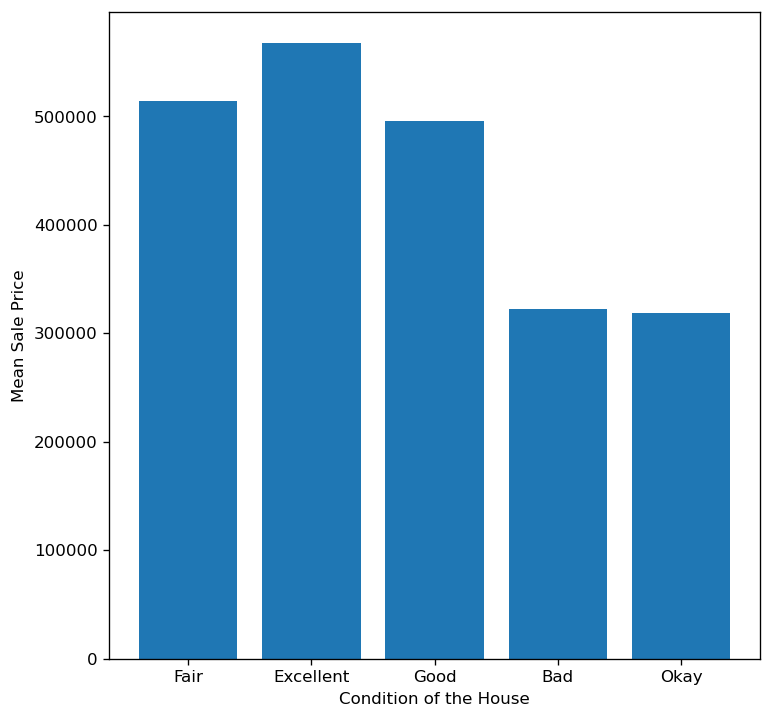

In [20]:
plt.figure( figsize = (7,7), dpi = 120)

plt.bar( data['Condition of the House'].unique(), mean)
plt.xlabel('Condition of the House')
plt.ylabel('Mean Sale Price')

In [21]:
mapping = {'Excellent':'Excellent',
           'Fair':'Good',
           'Good':'Good',
           'Okay':'Okay',
           'Bad':'Okay'}
data['Condition of the House'] = data['Condition of the House'].map(mapping)

In [22]:
mean = []

for i in data['Condition of the House'].unique():
    mean.append(data['Sale Price'][data['Condition of the House'] == i].mean())

Text(0, 0.5, 'Mean Sale Price')

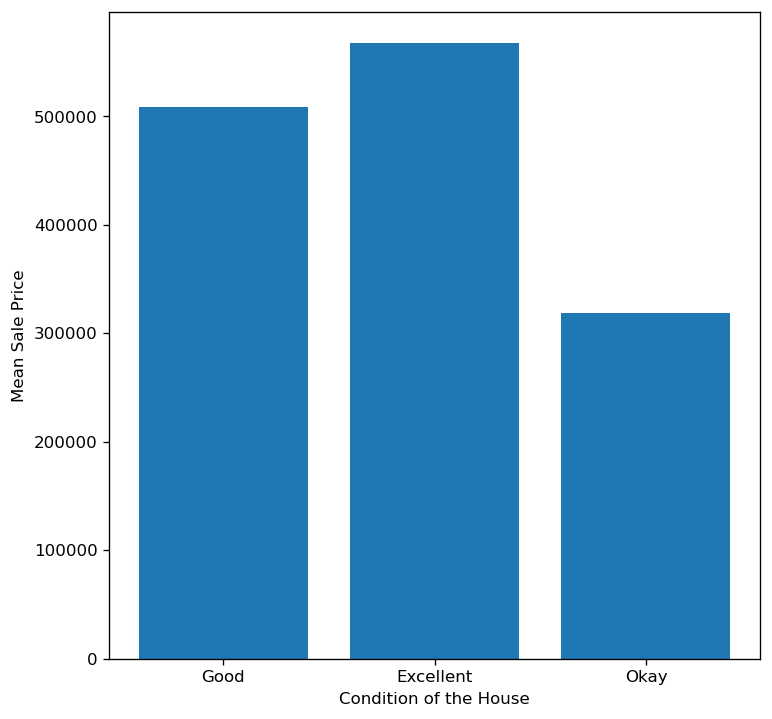

In [23]:
plt.figure( figsize = (7,7), dpi = 120)

plt.bar( data['Condition of the House'].unique(), mean)
plt.xlabel('Condition of the House')
plt.ylabel('Mean Sale Price')

In [25]:
len(data['Age of House (in Years)'].unique())

116

In [26]:
data['Age of House (in Years)'].max()

118

In [27]:
data['Age of House (in Years)'].min()

3

In [28]:
def age_of_house(x):
    if x < 10:
        x = 'new'
    elif x < 50:
        x = 'old'
    else:
        x = 'very old'
    return x    

In [29]:
cat_house_age = data['Age of House (in Years)'].map(age_of_house)
cat_house_age.unique()

array(['very old', 'old', 'new'], dtype=object)

In [32]:
data['Date House was Sold'].head()

0     14 October 2017
1    14 December 2017
2    15 February 2016
3    14 December 2017
4    15 February 2016
Name: Date House was Sold, dtype: object

In [36]:
time = pd.DatetimeIndex(data['Date House was Sold'])
data['year_sold'] = time.year
data['month_sold'] = time.month
data['weekday_sold'] = time.day_name() # Use day_name() method to get the weekday name
data['date_sold'] = time.days_in_month

data[['year_sold','month_sold','weekday_sold','date_sold']].head()

,year_sold,month_sold,weekday_sold,date_sold
0,2017,10,Saturday,31
1,2017,12,Thursday,31
2,2016,2,Monday,29
3,2017,12,Thursday,31
4,2016,2,Monday,29


In [40]:
def luxury_home(row):
    count = 0
    if row[0] == 'Yes':
        count = count+1
    if row[1] in ['Good', 'Excellent']:
        count = count+1
    if row[2] >= 8:
        count = count+1
    if count >= 2:
        return 'Yes'
    else:
        return 'No'
    
data['luxury_home'] = data[['Waterfront View', 'Condition of the House', 'Overall Grade']].apply(luxury_home, axis = 1)  

data['luxury_home'].unique()

array(['No', 'Yes'], dtype=object)

In [41]:
luxury = data.pivot_table(values ="Sale Price", columns = 'luxury_home', aggfunc = 'mean')
luxury

luxury_home,No,Yes
Sale Price,380385.64475,655067.166021


Text(0, 0.5, 'Mean Sale Price')

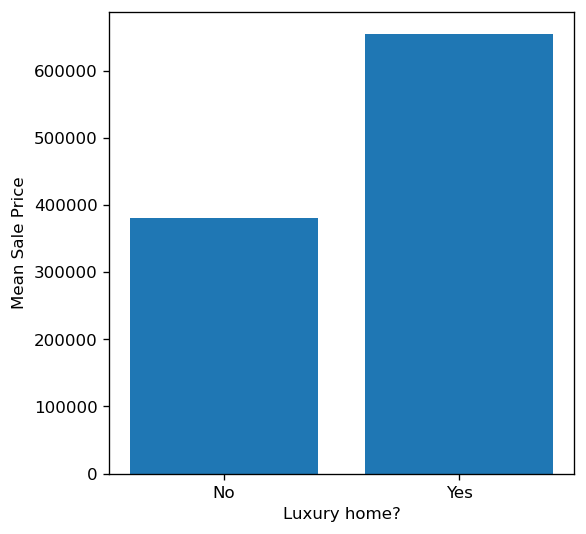

In [42]:
plt.figure( figsize = (5,5), dpi = 120)
plt.bar(luxury.columns, luxury.iloc[0])
plt.xlabel('Luxury home?')
plt.ylabel('Mean Sale Price')